# ЛАБОРАТОРНАЯ № 1. Детекция автомобилей на видеопотоке со статической камеры методом вычитания фона (Background Subtraction)

**Цель лабораторной:**
1. Изучить классический алгоритм для детекции движущихся объектов.
2. Научиться выделять движущиеся объекты (автомобили) на видеопотоке со статической камеры, используя классический метод вычитания фона. Построить модель фона (опорный кадр) путём усреднения кадров за заданный интервал времени, реализовать полный пайплайн обработки: вычисление абсолютной разности с опорным кадром → пороговая бинаризация → морфологические операции (dilate/erode) → поиск связных компонент → фильтрация по площади → построение bounding box. Провести анализ качества детекции на разных кадрах, замерить производительность алгоритма на CPU и сделать вывод о применимости метода в реальном времени.

**Источники:**
1. Chris Stauffer, W.E.L. Grimson Adaptive Background Mixture Models for Real-Time Tracking https://www.researchgate.net/publication/3813345_Adaptive_Background_Mixture_Models_for_Real-Time_Tracking
2. Python OpenCV - Вычитание фона: https://www.geeksforgeeks.org/python/python-opencv-background-subtraction/

## Импорт библиотек

In [55]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Загрузка видео

In [74]:
cap = cv2.VideoCapture('./data/cars.mp4')

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
print(f'FPS: {fps}')

frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    # OpenCV отдаёт BGR — конвертируем в RGB, если нужно
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame_rgb)

cap.release()

frames = np.array(frames)
print(frames.shape, frames.dtype)

FPS: 25.0
(750, 360, 640, 3) uint8


## Создание опорного изображения

In [75]:
background = np.mean(frames, axis=0).astype(np.uint8)

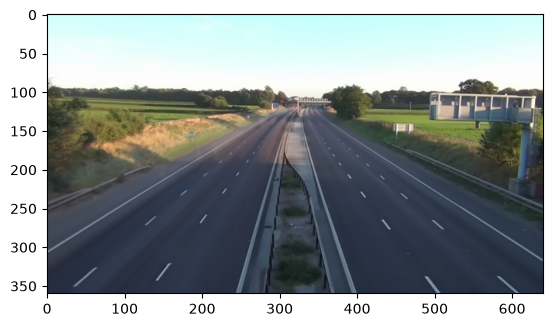

In [76]:
plt.imshow(background)
plt.show()

## Разность кадров видео с опорным изображением

In [77]:
difference = np.abs(frames.astype(np.int16) - background.astype(np.int16))

## Переводим разницу в оттенки серого

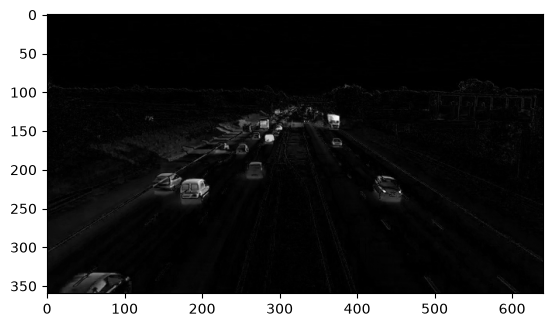

In [78]:
to_gray = np.array([0.2989, 0.5870, 0.114]).reshape(3,1)
difference_gray = (difference @ to_gray).reshape(difference.shape[:-1])

plt.imshow(difference_gray[0], cmap='gray')
plt.show()

## Проводим пороговую бинаризацию

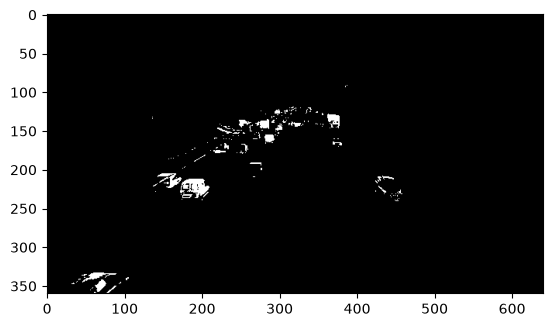

In [79]:
difference_bin = (difference_gray > 50).astype(np.uint8) * 255

plt.imshow(difference_bin[0], cmap='gray')
plt.show()

## Применяем морфологические операции (delate -> erode)

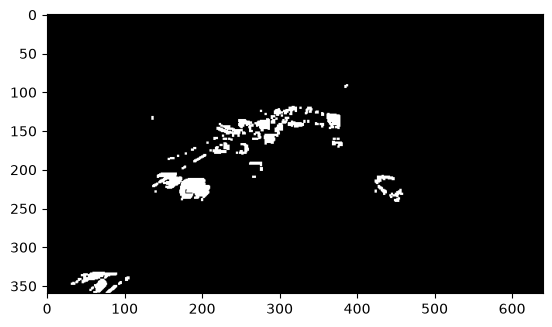

In [80]:
kernel_dilate = np.ones((3, 3), np.uint8)

difference_dilated = np.empty_like(difference_bin)
for i in range(difference_bin.shape[0]):
    difference_dilated[i] = cv2.dilate(difference_bin[i], kernel_dilate)

plt.imshow(difference_dilated[0], cmap='gray')
plt.show()

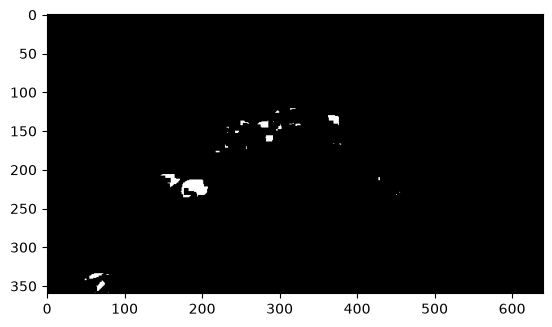

In [81]:
kernel_erode = np.ones((5, 5), np.uint8)

difference_eroded = np.empty_like(difference_dilated)
for i in range(difference_dilated.shape[0]):
    difference_eroded[i] = cv2.erode(difference_dilated[i], kernel_erode)

plt.imshow(difference_eroded[0], cmap='gray')
plt.show()

## Анализ связных компонент и фильтрация шума

Находим связные компоненты на бинарной маске с использованием 8-связности, получаем статистические характеристики каждой компоненты

In [82]:
num_labels_arr = []
labels_arr = []
stats_arr = []
for i in range(difference_eroded.shape[0]):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        difference_eroded[i], 
        connectivity=8
    )

    num_labels_arr.append(num_labels)
    labels_arr.append(labels)
    stats_arr.append(stats)

num_labels_arr = np.array(num_labels_arr)
labels_arr = np.array(labels_arr)
# stats_arr оставляем списком, так как форма неоднородна

print(f'Колличество компонент на первом кадре: {num_labels_arr[0]}')
print(labels[0].shape)
print(stats[0].shape)

Колличество компонент на первом кадре: 31
(640,)
(5,)


Фильтруем компоненты по площади (менее 100 пикселей), строим bounding box для оставшихся компонент, отрисовываем зеленые рамки на исходных кадрах

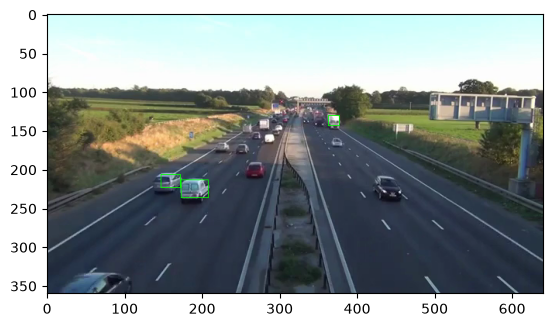

In [83]:
min_area = 100
result_frames = frames.copy()
for i in range(frames.shape[0]):
    num_labels = num_labels_arr[i]
    stats = stats_arr[i]
    for j in range(1, num_labels):
        x, y, w, h, area = stats[j]
        if area < min_area: continue
        cv2.rectangle(result_frames[i], (x, y), (x + w, y + h), (0, 255, 0), 1)

plt.imshow(result_frames[0])
plt.show()

## Сохранение результата

In [ ]:
H, W = result_frames.shape[1:3]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('result.mp4', fourcc, fps, (W, H))

for frame_rgb in result_frames:
    # RGB -> BGR для OpenCV
    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    out.write(frame_bgr)

out.release()

Сохранено: result.mp4 (750 кадров, 25.0 fps, 640x360)
